## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors
Anand Venkatesan: Hypothesis, Data, Background Research, Writing - original draft
Aviraj Singh Khanuja: Data, Hypothesis, Research Question, Writing - original draft 
Martin Gama Jr: Project administration, Background Research, Ethics, Writing - review & editing
Adrian Chow: Ethics, Background research, Writing - review & editing

# Research Question

How do PM₂.₅ and ozone concentrations correlate to respiratory hospital admission rates across U.S counties and which of the two contribute more?


## Background and Prior Work

Air pollution is one of the most significant environmental threats to public health in the United States and globally. In the United States, EPA regulates six criteria pollutants under the National Ambient Air Quality Standards (NAAQS). Among these, fine particulate matter (PM2.5) and ground-level ozone (O3) have been most consistently linked to respiratory morbidity and increased hospital utilization (U.S. EPA, 2024). Despite decades of regulation under the Clean Air Act, respiratory diseases remain a leading cause of hospitalization in the United States, raising the question of how closely air quality tracks with hospital admission patterns.

PM2.5 refers to airborne particles with a diameter of 2.5 micrometers or less. Due to their extremely small size, these particles can bypass the body’s airway defenses and deposit deep in the alveoli (Xing et al., 2016). Once deposited, it triggers a cascade of harmful biological responses, like increasing the production of reactive oxygen species (ROS) in lung tissue, leading to oxidative stress, which can damage the epithelial barrier of the airways, increase susceptibility to respiratory infections, and worsen chronic conditions such as asthma and chronic obstructive pulmonary disease (COPD) (Xing et al., 2016; Li et al., 2022).

Epidemiological evidence strongly supports a positive association between PM₂.₅ exposure and respiratory hospitalizations. Zanobetti et al. (2009) found that a 10 μg/m³ increase in PM₂.₅ across 26 U.S. communities was associated with a 2.07% increase in respiratory admissions, with stronger effects in communities where PM₂.₅ contained more combustion-related components. Dominici et al. (2006) confirmed this pattern across 204 counties using Medicare data, though the association was stronger in eastern U.S. counties than western ones, suggesting the relationship may vary by region.

Ground-level ozone, unlike PM₂.₅, is not emitted directly but forms through photochemical reactions between nitrogen oxides and volatile organic compounds in sunlight (U.S. EPA, 2024). This means ozone concentrations are highly seasonal, peaking in summer and dropping in winter. This is the opposite of PM₂.₅, which tends to be elevated in winter when temperature inversions trap pollutants near the surface (Vu et al., 2022). This seasonal divergence is important because annual averages could mask seasonal spikes.

Biologically, ozone is a potent respiratory irritant. It causes bronchial inflammation, airway hyperresponsiveness, and impaired lung function upon inhalation (Lim et al., 2019). However, while ozone is linked to asthma and COPD exacerbations, its association with broader respiratory hospitalizations has been less consistent across studies than the evidence for PM₂.₅ (Zheng et al., 2021; ALA, 2025).

Most existing studies have examined PM₂.₅ and ozone individually within single cities or regions. This project compares both pollutants across U.S. counties to determine which shows a stronger association with respiratory hospitalizations.

# Hypothesis


Based on our background research, we hypothesize the following:

First, we predict that there is a significant positive association between air pollution concentrations and respiratory hospital admission rates at the county level. This prediction is grounded in the consistent epidemiological findings from multiple large-scale U.S. studies.

Second, we predict that PM2.5 will show a stronger association with respiratory hospital admission rates than ozone when examining annual county-level data. This is because of the seasonal nature of the two pollutants. Ozone formation depends on sunlight, its concentrations peak during summer and negligible during winter. PM2.5, by contrast, poses a year-round risk and is often elevated during winter. Thus, we hypothesize while examining annual county-level averages, ozone’s contribution to be lesser. Furthermore, PM2.5’s mechanism of harm involves deep alveolar deposition and inflammatory responses that can damage multiple organs. Ozone primarily affects the upper airways and bronchial passages.

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [2]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# the fully processed dataset
df = pd.read_csv("data/01-interim/epa_air_quality_pm25_ozone_2023.csv")

pm25_df = df[df["Parameter Name"] == "PM2.5 - Local Conditions"]

ozone_df = df[df["Parameter Name"] == "Ozone"]
# preview data
df.head()

,county_fips,State Name,County Name,Year,Parameter Name,Sample Duration,Units of Measure,Arithmetic Mean,Observation Count,Observation Percent,Latitude,Longitude
0,1003,Alabama,Baldwin,2023,Ozone,1 HOUR,Parts per million,0.047836,5148,92,30.497478,-87.880258
1,1003,Alabama,Baldwin,2023,Ozone,8-HR RUN AVG BEGIN HOUR,Parts per million,0.043288,5345,91,30.497478,-87.880258
2,1003,Alabama,Baldwin,2023,Ozone,8-HR RUN AVG BEGIN HOUR,Parts per million,0.043288,5345,91,30.497478,-87.880258
3,1003,Alabama,Baldwin,2023,Ozone,8-HR RUN AVG BEGIN HOUR,Parts per million,0.043255,3789,88,30.497478,-87.880258
4,1003,Alabama,Baldwin,2023,PM2.5 - Local Conditions,1 HOUR,Micrograms/cubic meter (LC),7.690417,8150,93,30.497478,-87.880258


### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32326 entries, 0 to 32325
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   county_fips          32326 non-null  int64  
 1   State Name           32326 non-null  object 
 2   County Name          32326 non-null  object 
 3   Year                 32326 non-null  int64  
 4   Parameter Name       32326 non-null  object 
 5   Sample Duration      32326 non-null  object 
 6   Units of Measure     32326 non-null  object 
 7   Arithmetic Mean      32322 non-null  float64
 8   Observation Count    32326 non-null  int64  
 9   Observation Percent  32326 non-null  int64  
 10  Latitude             32326 non-null  float64
 11  Longitude            32326 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 3.0+ MB


In [18]:
df.describe()

,county_fips,Year,Arithmetic Mean,Observation Count,Observation Percent,Latitude,Longitude
count,32326.000000,32326.0,32322.000000,32326.000000,32326.000000,32326.000000,32326.000000
mean,28431.096053,2023.0,6.954423,1857.596424,87.179484,38.582015,-91.599738
std,15408.792851,0.0,3.869509,2972.123890,19.944873,5.335803,16.063918
min,1003.000000,2023.0,0.014442,1.000000,0.000000,18.009558,-158.088613
25%,17031.000000,2023.0,5.213605,138.000000,87.000000,35.356615,-99.763424
50%,27139.000000,2023.0,7.997778,321.000000,97.000000,39.464872,-87.274512
75%,40135.000000,2023.0,9.575691,2218.750000,99.000000,41.679867,-80.256944
max,80026.000000,2023.0,28.664706,8759.000000,100.000000,64.845930,-65.618888


In [19]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

Arithmetic Mean        4
county_fips            0
State Name             0
County Name            0
Year                   0
Parameter Name         0
Sample Duration        0
Units of Measure       0
Observation Count      0
Observation Percent    0
Latitude               0
Longitude              0
dtype: int64

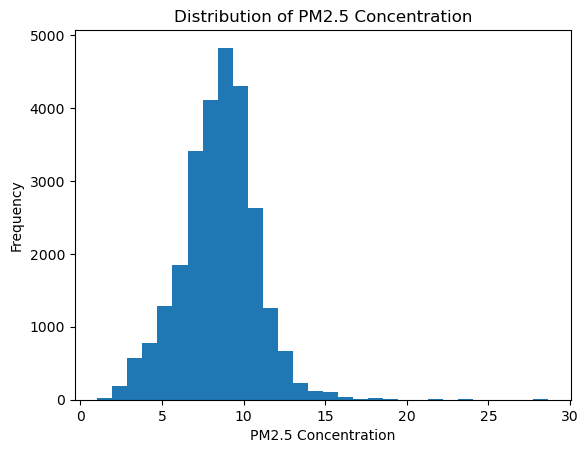

In [20]:
# PM2.5 histogram
plt.hist(pm25_df["Arithmetic Mean"].dropna(), bins=30)

plt.xlabel("PM2.5 Concentration")
plt.ylabel("Frequency")
plt.title("Distribution of PM2.5 Concentration")

plt.show()

The distribution of PM2.5 concentrations appears slightly right-skewed, with most monitoring locations reporting concentrations between approximately 5 and 10 units. However, a smaller number of monitors recorded much higher PM2.5 concentrations, creating a long right tail in the distribution. This suggests that while most counties experience moderate PM2.5 levels, certain areas may experience substantially worse particulate pollution exposure.

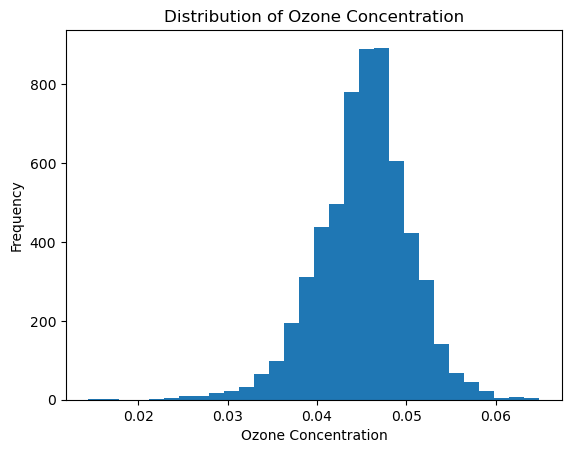

In [21]:
# Ozone histogram
plt.hist(ozone_df["Arithmetic Mean"].dropna(), bins=30)

plt.xlabel("Ozone Concentration")
plt.ylabel("Frequency")
plt.title("Distribution of Ozone Concentration")

plt.show()

The ozone concentration distribution appears more normally distributed and concentrated around a narrower range of values compared to PM2.5 concentrations. Most ozone measurements cluster between approximately 0.04 and 0.05, with fewer extreme outliers. This suggests ozone levels may be more geographically consistent across monitored counties than PM2.5 levels.

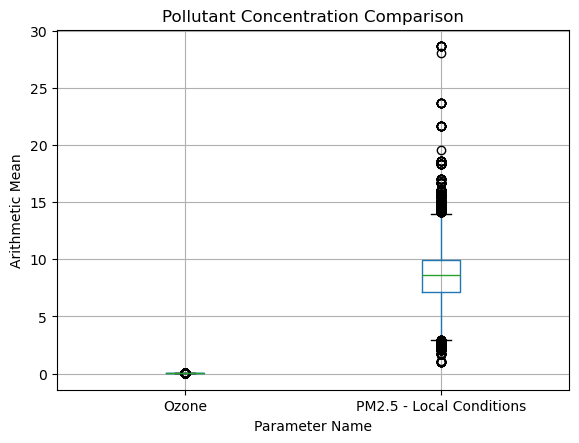

In [22]:
# Boxplot comparison
pollutants = df[df["Parameter Name"].isin(["Ozone", "PM2.5 - Local Conditions"])]

pollutants.boxplot(column="Arithmetic Mean", by="Parameter Name")

plt.ylabel("Arithmetic Mean")
plt.title("Pollutant Concentration Comparison")
plt.suptitle("")

plt.show()

The boxplot comparison highlights substantial differences in the variability of PM2.5 and ozone concentrations. PM2.5 concentrations show a much wider spread and many large value outliers, indicating that some monitoring locations experience significantly elevated particulate pollution levels. In contrast, ozone concentrations vary within a much smaller numerical range. This suggests PM2.5 pollution may differ more dramatically across regions than ozone pollution.

It is important to note that the ozone and PM2.5 are measured in different units and scales, the numerical ranges should not be interpreted as direct comparisons of pollutant severity.

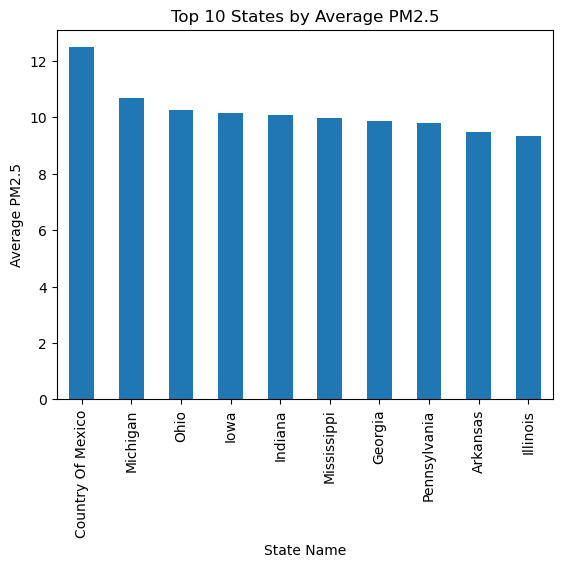

In [23]:
# Top 10 states by average PM2.5
top_states = (
    pm25_df.groupby("State Name")["Arithmetic Mean"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_states.plot(kind="bar")

plt.ylabel("Average PM2.5")
plt.title("Top 10 States by Average PM2.5")

plt.show()

The top 10 states with the highest average PM2.5 concentrations include New Mexico, Michigan, Ohio, Iowa, Indiana, Mississippi, Georgia, Pennsylvania, Arkansas, and Illinois. New Mexico had the highest observed average PM2.5 concentration at approximately 13, while the remaining states ranged between roughly 9 and 10.

The relatively small spread between most states suggests that many states experience somewhat similar average PM2.5 levels, although a few states stand out with noticeably higher concentrations. These differences may reflect variation in industrial activity, transportation density, urbanization, wildfire exposure, agricultural emissions, or regional climate conditions.

The presence of Midwestern and Southern states among the highest PM2.5 averages may indicate the influence of manufacturing activity, fossil fuel usage, and agricultural pollution sources. However, these results should be interpreted cautiously because the EPA dataset is monitor-level rather than population-level. Some states may contain more monitoring stations than others, and counties without monitors are not represented in the dataset.

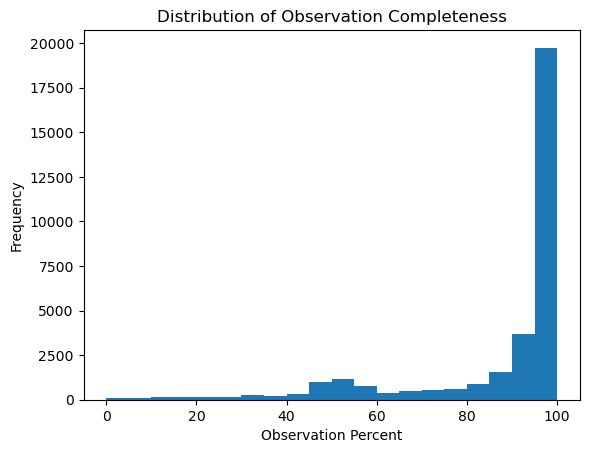

In [24]:
plt.hist(df["Observation Percent"], bins=20)

plt.xlabel("Observation Percent")
plt.ylabel("Frequency")
plt.title("Distribution of Observation Completeness")

plt.show()

The distribution of observation completeness is strongly left-skewed, indicating that most monitoring stations recorded very high percentages of expected observations during the year. This suggests that the majority of annual pollutant averages are based on relatively complete monitoring records, which improves the reliability of the dataset overall.

However, a smaller number of monitoring locations had substantially lower observation percentages, meaning their annual averages were calculated from less complete data. These incomplete observations may introduce additional uncertainty or reduce the reliability of pollutant estimates for certain counties. This limitation is important to consider when interpreting geographic differences in pollution levels.

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [ ]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them